<a href="https://colab.research.google.com/github/ilia-kuznetsov-hds/statistical_modelling/blob/main/HDAT_9600_01_EDA_of_Blood_Storage_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

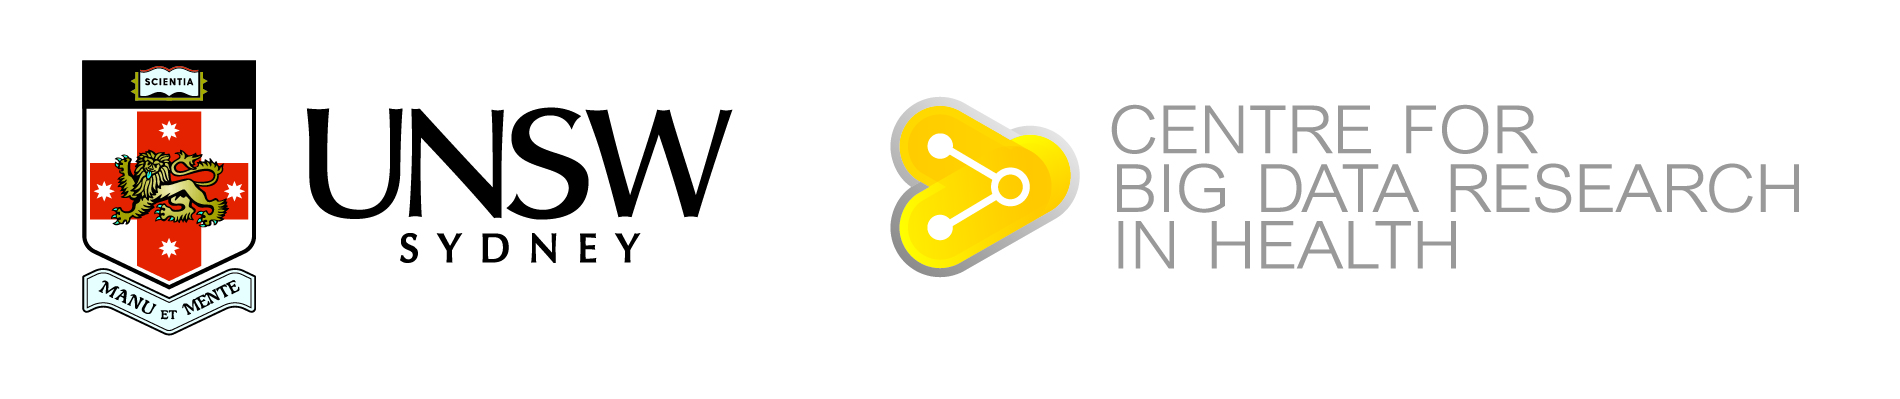

### Notebook Overview: EDA of Blood Storage Dataset
This notebook performs an Exploratory Data Analysis (EDA) on the `blood_storage` dataset from the `medicaldata` R package.

**Acknowledgments:**
- This notebook is part of the **Statistical Modelling I course at UNSW (T2 2024)**.
- Study examples and tasks were authored by [Andrew Blance](https://www.unsw.edu.au/research/cbdrh/about-us/people/andrew-blance).

**Key Steps Included:**
- **Data Acquisition:** Installation and loading of the `medicaldata` package and the `blood_storage` data frame.
- **Structural Analysis:** Inspection of variable types, dimensions (316 obs, 20 variables), and naming conventions.
- **Data Cleaning:** Identification of missing values (`NA`s) in variables like `PVol`, `PreopPSA`, and `TVol`.
- **Univariate EDA:** Visualizing distributions using histograms and frequency tables for both continuous (Age, PSA, Volume) and categorical (RBC group, Race, Recurrence) data.
- **Bivariate EDA:** Exploring relationships between variables using boxplots, frequency polygons, and scatterplots, specifically focusing on factors affecting `TimeToRecurrence`.
- **Correlation Analysis:** Generation of a Pearson correlation matrix to identify multicollinearity and linear dependencies between clinical features.

# The dataset

The ‘medicaldata’ package "Provides access to well-documented medical datasets for teaching. Featuring several from the Teaching of Statistics in the Health Sciences [website](https://www.causeweb.org/tshs/category/dataset/).

Each dataset is documented in three ways:
* a help file, which can be accessed with `help('dataset_name')`
* a pdf document describing the study, found [here](https://www.causeweb.org/tshs/datasets/Blood%20Storage%20Dataset%20Introduction.pdf)
* a pdf codebook, found [here](https://www.causeweb.org/tshs/datasets/Blood%20Storage%20Data%20Dictionary.pdf)

Copies of the PDFs have also been included in the 'hdat9600ch1_tbla' folder.

<br>

The following code cell installs the 'medicaldata' package, obtains the 'bloood_storage' dataset, and stores it for use as 'dat'.

In [16]:
# Install "medicaldata" package if not already installed
if(!"medicaldata" %in% installed.packages()) install.packages("medicaldata", repos = "https://cran.ms.unimelb.edu.au")
# Load the package
library(medicaldata)
# Obtain the required dataset and store as blood
dat <- medicaldata::blood_storage

In [17]:
# Install packages if not already installed
if(!"dplyr" %in% installed.packages()) install.packages("dplyr", repos = "https://cran.ms.unimelb.edu.au")
if(!"tidyr" %in% installed.packages()) install.packages("tidyr", repos = "https://cran.ms.unimelb.edu.au")
if(!"ggplot2" %in% installed.packages()) install.packages("ggplot2", repos = "https://cran.ms.unimelb.edu.au")
if(!"psych" %in% installed.packages()) install.packages("psych", repos = "https://cran.ms.unimelb.edu.au")

In [18]:
# This chunk calls the libraries. "dplyr" and "tidyr" are both very useful for manipulating data frames.
# "ggplot" is very useful for plots - it allows a greater degree of control over the appearance of plots.
# NOTE: the "tidyverse" package is an umbrella package that loads all three of these libraries in one go.
library(dplyr)
library(tidyr)
library(ggplot2)
# The "psych" package is an optional one - it enables a nice summary table through the describe function
# which can be helpful in EDA.
library(psych)

# EDA

## Investigate data structure


In [19]:
# Observations and variable counts
col <- ncol(dat)
row <-nrow(dat)

cat(row, "observations \n", col, "variables \n")

# List of variable names
# ls() will list the column names
var_names <- ls(dat)
cat("list of column names: \n", var_names, "\n")

# observe structure
# str() will provide the structure of the data frame as well as give you the number of obs and variables
structure <- str(dat)
cat("structure of data: \n", structure, "\n")

316 observations 
 20 variables 
list of column names: 
 AA AdjRadTherapy Age AnyAdjTherapy bGS BN+ Censor FamHx Median.RBC.Age OrganConfined PreopPSA PreopTherapy PVol RBC.Age.Group Recurrence sGS T.Stage TimeToRecurrence TVol Units 
'data.frame':	316 obs. of  20 variables:
 $ RBC.Age.Group   : num  3 3 3 2 2 3 3 1 1 2 ...
 $ Median.RBC.Age  : num  25 25 25 15 15 25 25 10 10 15 ...
 $ Age             : num  72.1 73.6 67.5 65.8 63.2 65.4 65.5 67.1 63.9 63 ...
 $ AA              : num  0 0 0 0 0 0 1 0 0 1 ...
 $ FamHx           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ PVol            : num  54 43.2 102.7 46 60 ...
 $ TVol            : num  3 3 1 1 2 2 2 3 2 2 ...
 $ T.Stage         : num  1 2 1 1 1 1 1 1 1 1 ...
 $ bGS             : num  3 2 3 1 2 1 1 1 1 2 ...
 $ BN+             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ OrganConfined   : num  0 1 1 1 1 0 1 0 1 1 ...
 $ PreopPSA        : num  14.08 10.5 6.98 4.4 21.4 ...
 $ PreopTherapy    : num  1 0 1 0 0 0 0 0 0 0 ...
 $ Units           : num  6 2 1

Analytical notes:
316 observations, 20 variables

20 numerical variables

According to the data dictionary, 14 columns **"RBC.Age.Group", "AA", "FamHx", "TVol", "T.Stage", "bGS", "BN+", "OrganConfined", "PreopTherapy", "sGS", "AnyAdjTherapy", "AdjRadTherapy", "Recurrence", "Censor"** are categorical and represented by numbers:

In [20]:
# vector of categorical columns
cat_var <- c("RBC.Age.Group", "AA","FamHx","TVol", "T.Stage","bGS","BN+",
"OrganConfined", "PreopTherapy", "sGS", "AnyAdjTherapy", "AdjRadTherapy", "Recurrence", "Censor")

In [21]:
# data filtered for categorical columns
cat_data <-dat[,cat_var]

6 columns **"Median.RBC.Age", "Age", "PVol", "PreopPSA", "Units", "TimeToRecurrence"** contain continious data:

In [22]:
cont_var <- c("Median.RBC.Age", "Age", "PVol", "PreopPSA", "Units", "TimeToRecurrence")

In [23]:
cont_data <-dat[,cont_var]

## Missing data

### Check for continious data

In [24]:
summary(cont_data)

 Median.RBC.Age       Age             PVol           PreopPSA     
 Min.   :10.00   Min.   :38.40   Min.   : 19.40   Min.   : 1.300  
 1st Qu.:10.00   1st Qu.:56.20   1st Qu.: 40.85   1st Qu.: 4.980  
 Median :15.00   Median :61.85   Median : 49.00   Median : 6.200  
 Mean   :16.71   Mean   :61.16   Mean   : 56.45   Mean   : 8.185  
 3rd Qu.:25.00   3rd Qu.:66.10   3rd Qu.: 64.05   3rd Qu.: 9.000  
 Max.   :25.00   Max.   :79.00   Max.   :274.00   Max.   :40.100  
                                 NA's   :9        NA's   :3       
     Units        TimeToRecurrence 
 Min.   : 1.000   Min.   :  0.270  
 1st Qu.: 2.000   1st Qu.:  7.585  
 Median : 2.000   Median : 25.300  
 Mean   : 2.456   Mean   : 32.918  
 3rd Qu.: 2.000   3rd Qu.: 52.035  
 Max.   :19.000   Max.   :103.600  
                  NA's   :1        

 - Variables with small number of missing values for **PVol**(9), **PreopPSA**(3), **TimeToRecurrence**(1).

### Check for categorical data

Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_count()`).”


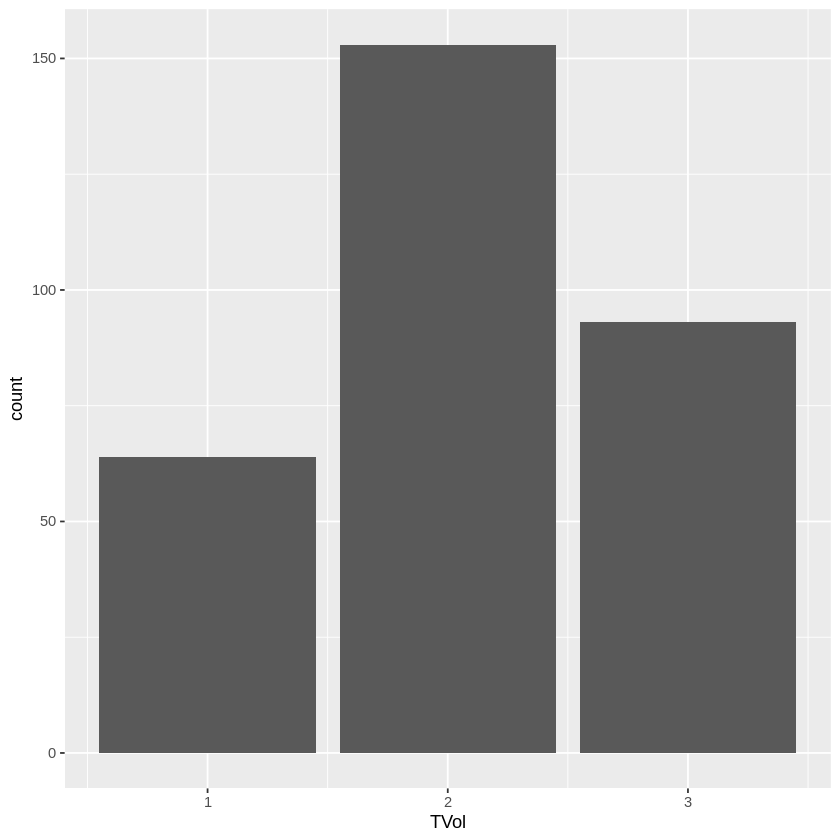

In [25]:
ggplot(data = dat) +
  geom_bar(mapping = aes(x = TVol))

Warning message:
“Removed 13 rows containing non-finite outside the scale range (`stat_count()`).”


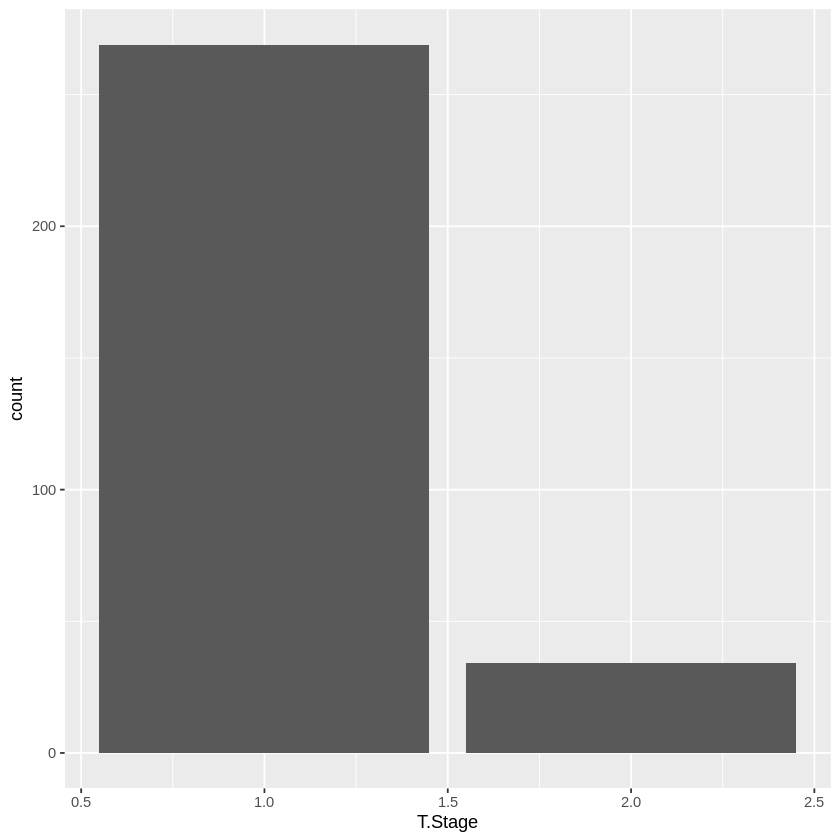

In [26]:
ggplot(data = dat) +
  geom_bar(mapping = aes(x = T.Stage))

In [27]:
# For categorical variables it may be easier to summarise in a table or series of tables, if you include
# the option "exclude=NULL" it will show the 'NA's.
for (col_name in cat_var) {
  cat(col_name)
  t1 <- table(cat_data[[col_name]], exclude = NULL)
  # Print the table with rough numbers
  print(t1)
  cat("\n")

  cat(col_name, "proportions")
  # Print the proportion table rounded to 2 digits
  print(round(prop.table(t1), digits = 2))
  cat("_____________ \n")
  cat("\n")
}

RBC.Age.Group
  1   2   3 
106 103 107 

RBC.Age.Group proportions
   1    2    3 
0.34 0.33 0.34 
_____________ 

AA
  0   1 
261  55 

AA proportions
   0    1 
0.83 0.17 
_____________ 

FamHx
  0   1 
248  68 

FamHx proportions
   0    1 
0.78 0.22 
_____________ 

TVol
   1    2    3 <NA> 
  64  153   93    6 

TVol proportions
   1    2    3 <NA> 
0.20 0.48 0.29 0.02 
_____________ 

T.Stage
   1    2 <NA> 
 269   34   13 

T.Stage proportions
   1    2 <NA> 
0.85 0.11 0.04 
_____________ 

bGS
   1    2    3 <NA> 
 189   93   32    2 

bGS proportions
   1    2    3 <NA> 
0.60 0.29 0.10 0.01 
_____________ 

BN+
  0   1 
298  18 

BN+ proportions
   0    1 
0.94 0.06 
_____________ 

OrganConfined
  0   1 
109 207 

OrganConfined proportions
   0    1 
0.34 0.66 
_____________ 

PreopTherapy
  0   1 
278  38 

PreopTherapy proportions
   0    1 
0.88 0.12 
_____________ 

sGS
  1   2   3   4 
 38  85 172  21 

sGS proportions
   1    2    3    4 
0.12 0.27 0.54 0.07 
__________

Analytical notes:  
* Most of the columns don't have missing values. TVol variable misses 6 entries (2% of total). TStage misses 13 (4% of total). bGS misses 2 (1% of total).  
* RBC age groups proportion is consistent with data dictionary.   
* 17% of participants were of African American race.  
* 22% of participants had a family history of disease.  
* 48% of patients had medium tumor volume, 20% - low, and 29% - extensive.
* 85% of patients attributed to clinical stage T1-­T2a, 11% - stage T2b­‐T3.  
* 60% of patients had biopsy Gleason scores between 0 and 6, 29% scored 7, and only 10% scored 8-10. Surgical Gleason score was not assigned in 12% of cases, in 27% no residual disease or score 0-6, 54% was score 7, and 7% of score 8-10.
* Bladder neck positivity in 6% of cases.  
* Organ confined is 66% of cases.  
* Only 12% had preoperative therapy.
* 2% had  adjuvant therapy.  
* Only 1 patient had Adjuvant radiation therapy.  
* Biochemical recurrence of prostate cancer identified in 17% of cases.  
* 83% of patients had Censoring indicator.

## Check univariate distributions

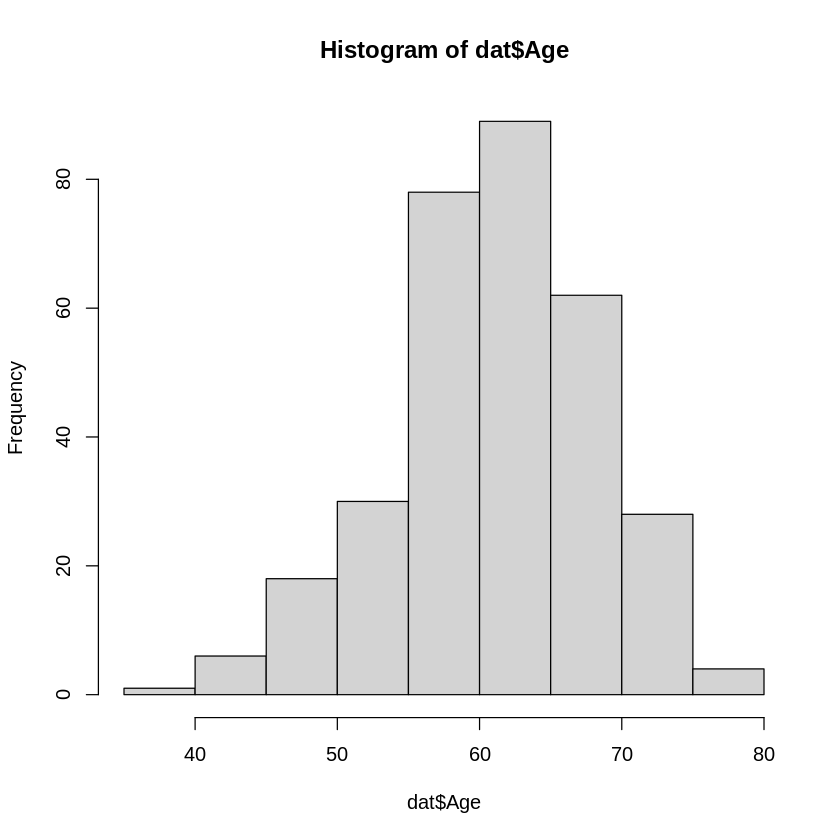

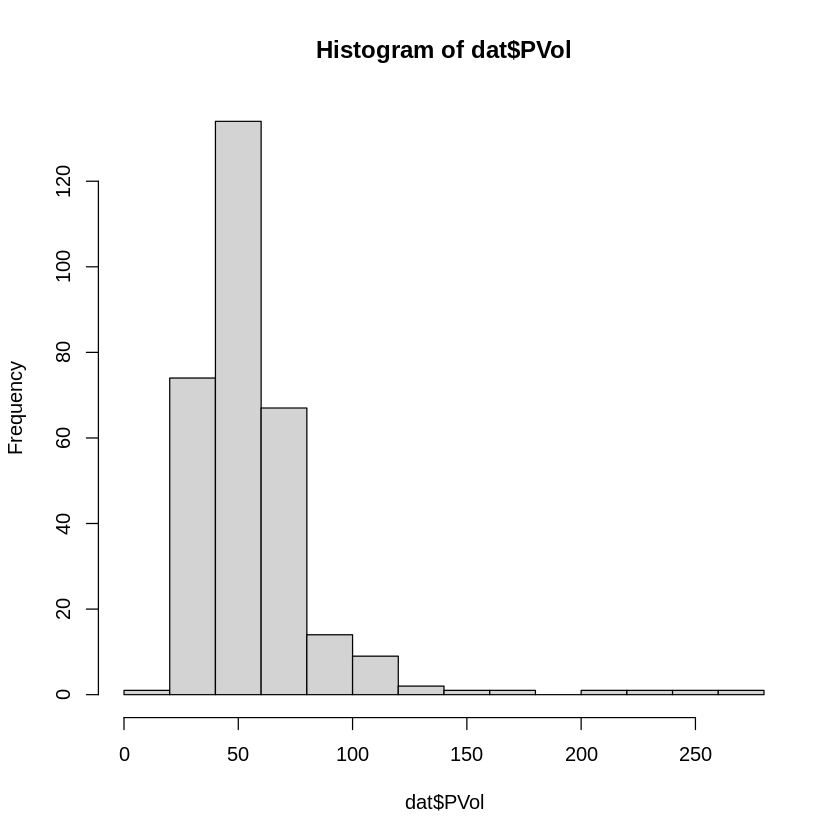

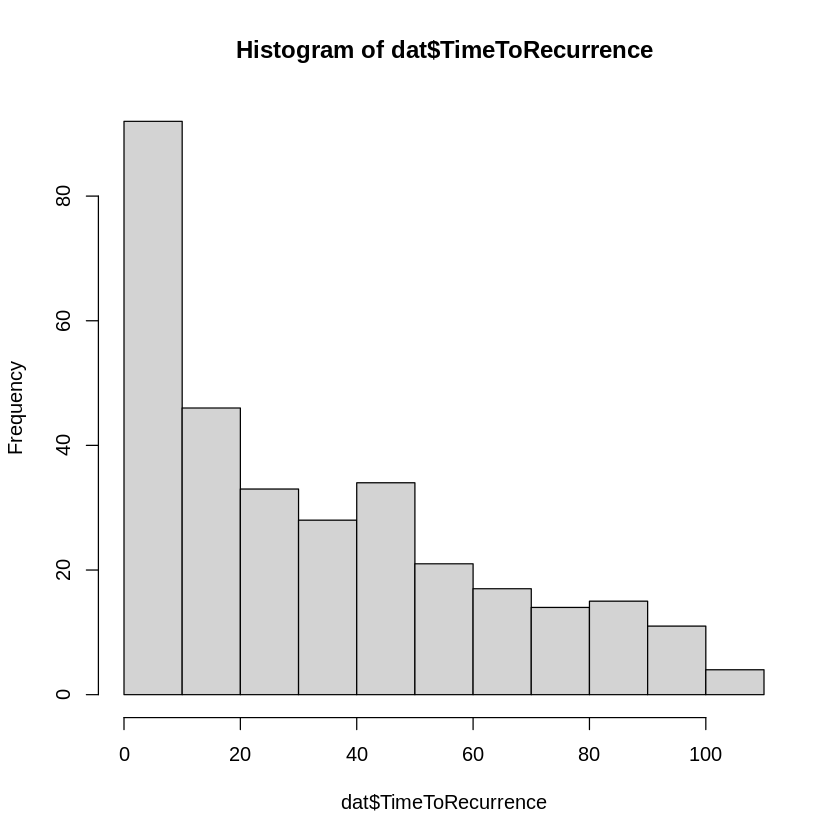

In [28]:
# The hist() function from base R will produce a standard histogram for continious variables.
hist(dat$Age)
hist(dat$PVol)
hist(dat$TimeToRecurrence)

Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_bin()`).”


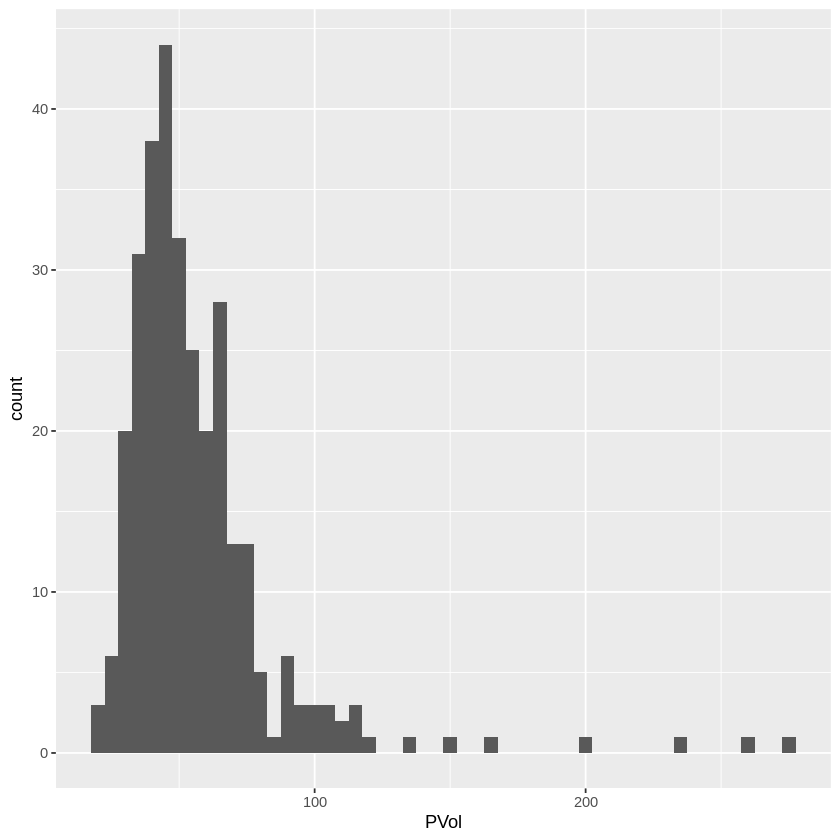

In [29]:
# Alternative histogram to examine the distribution of a continuous variable
ggplot(data = dat) +
  geom_histogram(mapping = aes(x = PVol), binwidth = 5)

In [30]:
# Divide TimeToRecurrence in 10 day bins and count
dat %>%
  count(cut_width(TimeToRecurrence, 10))

"cut_width(TimeToRecurrence, 10)",n
<fct>,<int>
"[-5,5]",64
"(5,15]",59
"(15,25]",34
"(25,35]",26
"(35,45]",34
"(45,55]",24
"(55,65]",21
"(65,75]",20
"(75,85]",12


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 13 rows containing non-finite outside the scale range (`stat_bin()`).”


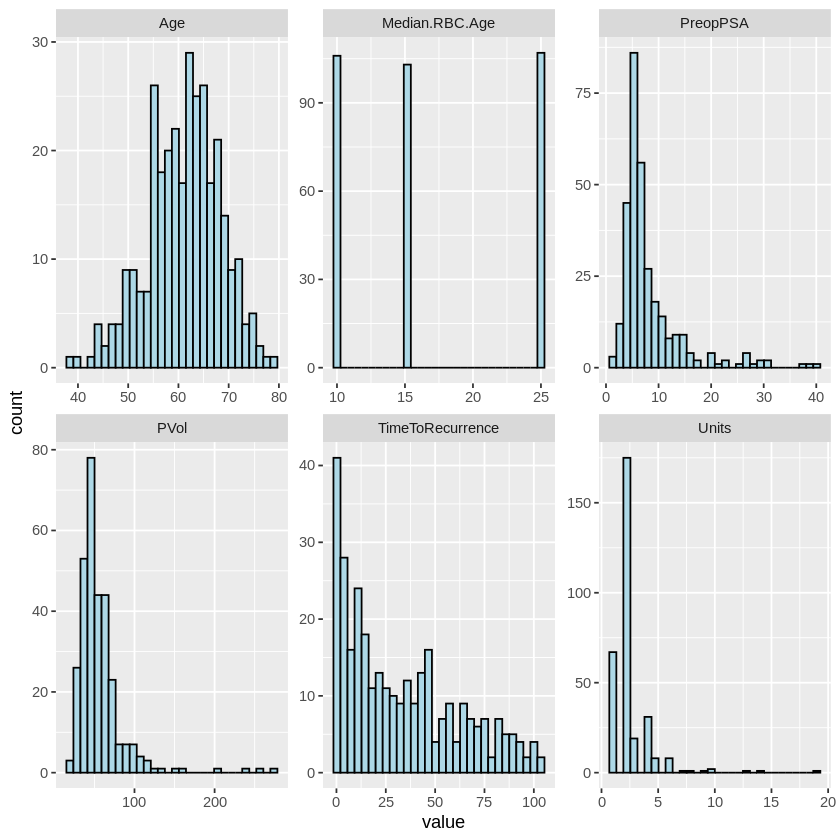

In [31]:
# For all continious variables at once.
# This code first reshapes the data and then uses a facet_wrap to plot the individual charts in a grid.
cont_data %>%
  gather() %>%
  ggplot(aes(value)) +
    facet_wrap(~ key, scales = "free") +
    geom_histogram(color='black', fill='lightblue')

Analytical notes:
* Age: Most patients are between 50 and 70 years old.   
* Median RBC age is confined to 3 numbers: 10, 15, and 25.  
* Units: most of the patients received less than 5 units of blood.  
* PVol: most patients have a prostate volume less than 100g.
* Time of recurrence: most recurrences happen in the first 50 days.
* PreopPSA: the majority of patients have a PSA level of less than 15.


In [32]:
# The describe function from the "Psych" package for continious variables:
des <- describe(cont_data)
des[,c("n","mean","sd","median","min","max","skew","kurtosis")]

,n,mean,sd,median,min,max,skew,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Median.RBC.Age,316,16.708861,6.281041,15.00,10.00,25.0,0.3635073,-1.53353026
Age,316,61.157278,7.240269,61.85,38.40,79.0,-0.3211943,-0.01281281
PVol,307,56.448208,30.198454,49.00,19.40,274.0,3.7087590,19.91320034
PreopPSA,313,8.185144,6.005431,6.20,1.30,40.1,2.6440552,8.11402762
Units,316,2.455696,1.899356,2.00,1.00,19.0,4.1679242,25.40334684
TimeToRecurrence,315,32.917873,28.558791,25.30,0.27,103.6,0.6994940,-0.62920160


Analytical notes:  
* Age: The youngest patient is 38 years old, while median age is 49. The most senior patient is 79 years old.   
* Prostate volume (PVol): median is 49g with the maximum 274g.  
* Preoperative prostate specific antigen (PSA): median is 49 ng/ml with maximum of 40.1.  
* Number of transfusion units: median is 2 with the max of 19 units.

## Co-Variation

The Co-Variation section explores the relationships between two or more variables to see if they vary together in a predictable way.

### Categorical vs. Continuous  

We use geom_freqpoly and geom_boxplot to see how continuous variables like TimeToRecurrence differ across categories like Race (AA), RBC.Age.Group, and Family History (FamHx).

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


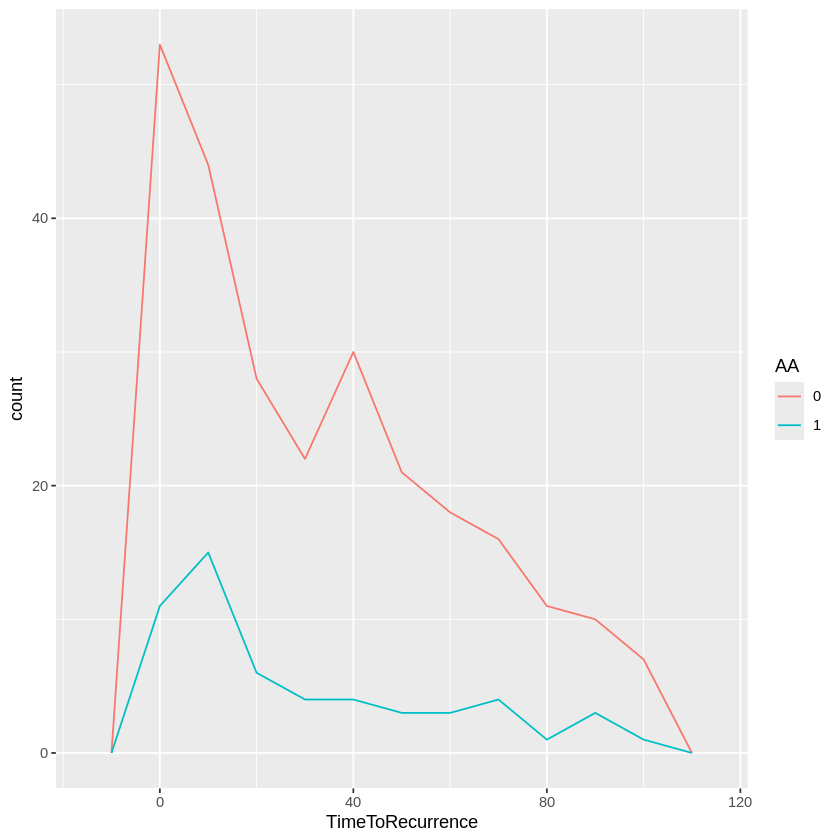

In [34]:
dat$AA = as.factor(dat$AA)
ggplot(data = dat, mapping = aes(x = TimeToRecurrence)) +
  geom_freqpoly(mapping = aes(colour = AA), binwidth = 10)

Analytical notes:
* African American patients have a peak of reccurence later than non-AA patients and stedy decline of recurrence after it.
* Non-AA patients have a 2 peaks of recurrence, the second approximately at 40 days.

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


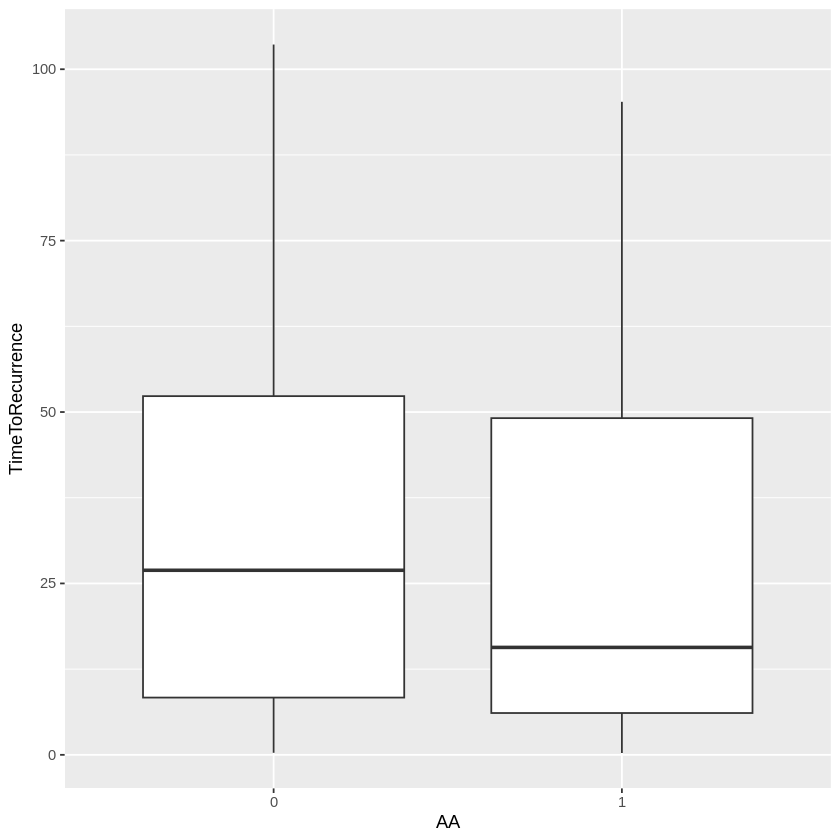

In [35]:
ggplot(data = dat, mapping = aes(x = AA, y = TimeToRecurrence)) +
  geom_boxplot()

Analytical notes:
* The median recurrence time is less for AA patients than non-AA patients.

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


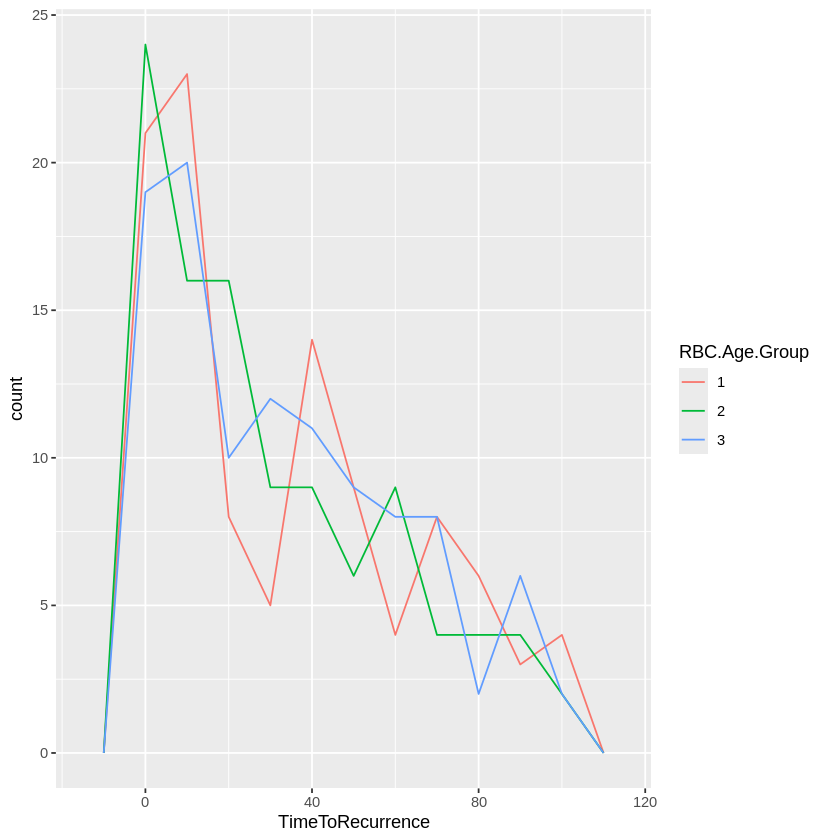

In [36]:
dat$RBC.Age.Group = as.factor(dat$RBC.Age.Group)
ggplot(data = dat, mapping = aes(x = TimeToRecurrence)) +
  geom_freqpoly(mapping = aes(colour = RBC.Age.Group), binwidth = 10)

Analytical notes:
* There is a general decline in the count of recurrences as time progresses across all RBC Age Groups.
* The majority of recurrences happen relatively early across all RBC Age Groups (approximately the first 20 days)
* RBC Age Group 1 shows more variability in recurrence counts in the middle of the graph, with the second peak at 40 days.

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


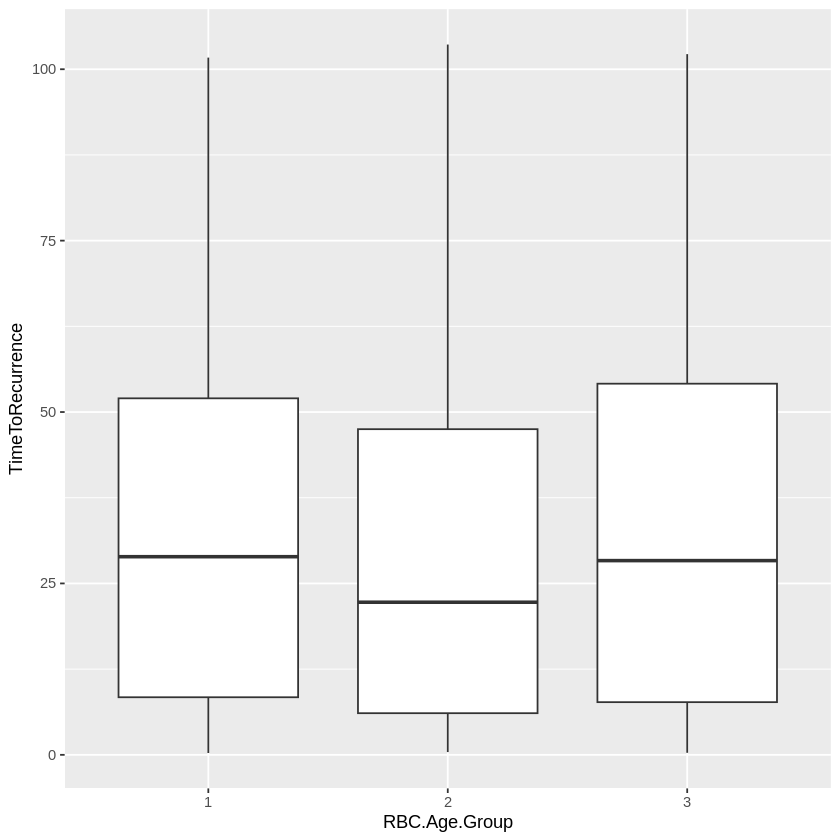

In [37]:
ggplot(data = dat, mapping = aes(x = RBC.Age.Group, y = TimeToRecurrence)) +
  geom_boxplot()

Analytical notes:
The box plots indicate that the median time to recurrence is slightly lower for RBC Age Group 2 compared to the other groups, but the overall spread and distribution are quite similar across all three groups.

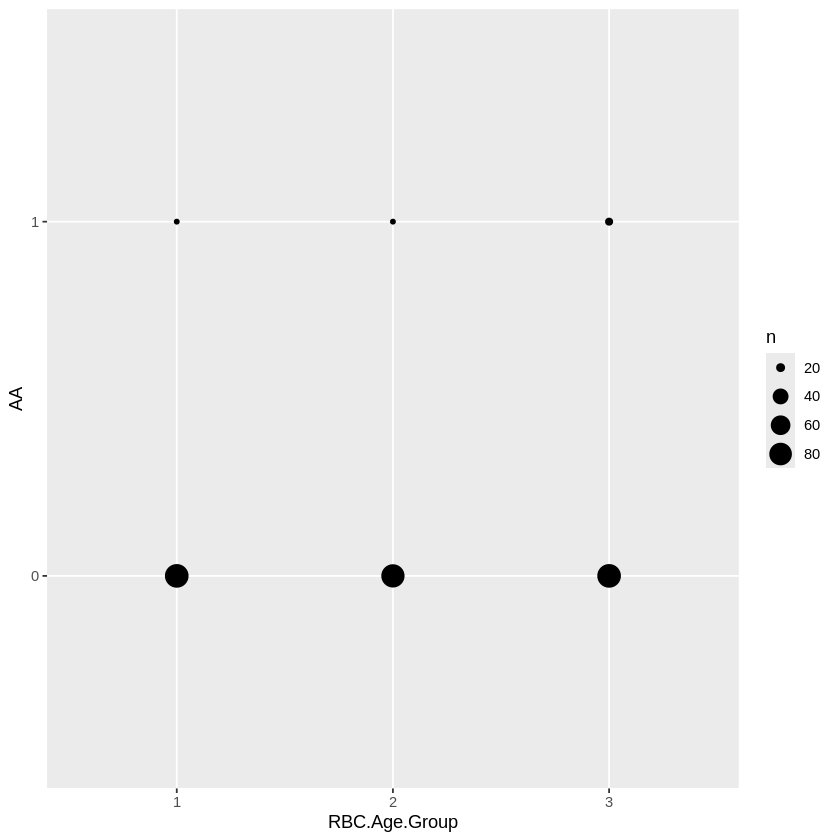

In [38]:
ggplot(data = dat) +
  geom_count(mapping = aes(x = RBC.Age.Group, y = AA))

Analytical notes:
* The recurrence rate for AA patients receiving the RBC group age 3 is slightly higher than those receiving groups 1 and 2.

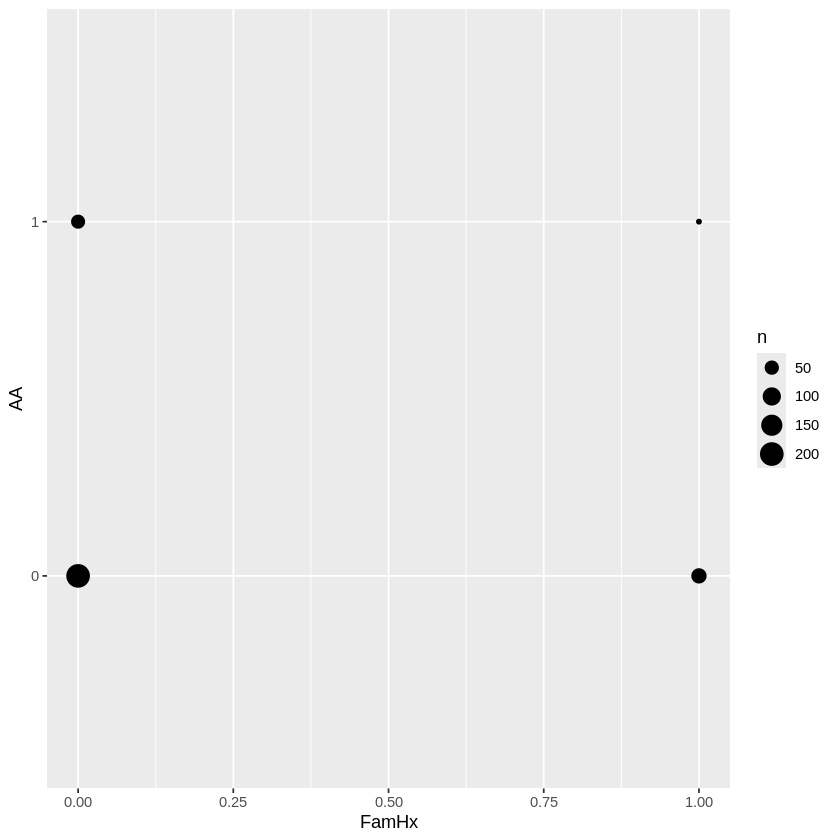

In [39]:
ggplot(data = dat) +
  geom_count(mapping = aes(x = FamHx, y = AA))

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


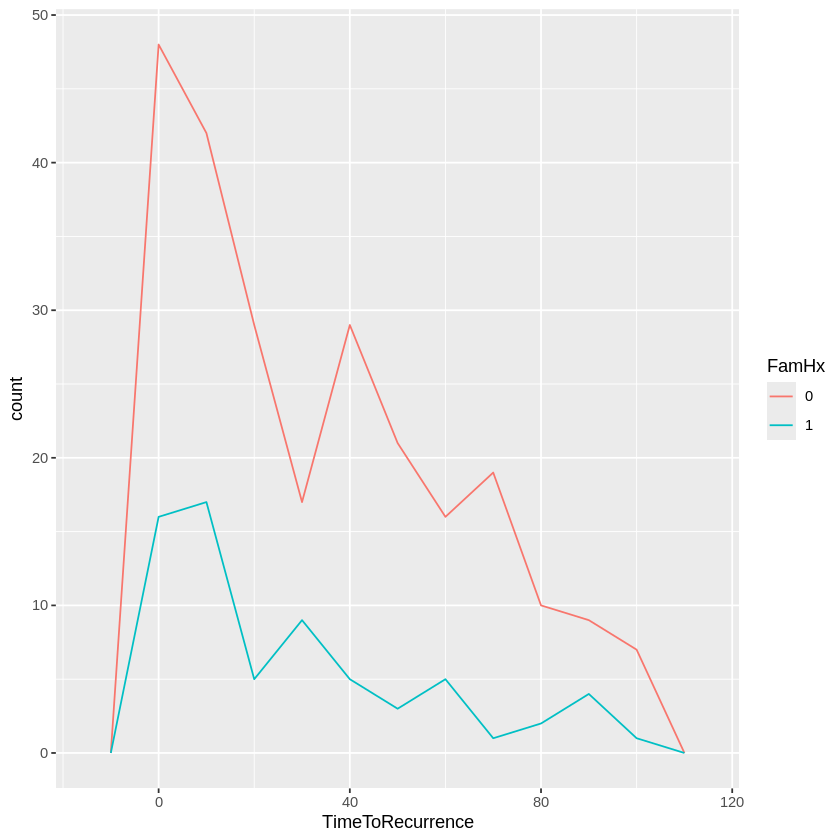

In [41]:
dat$FamHx = as.factor(dat$FamHx)
ggplot(data = dat, mapping = aes(x = TimeToRecurrence)) +
  geom_freqpoly(mapping = aes(colour = FamHx), binwidth = 10)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


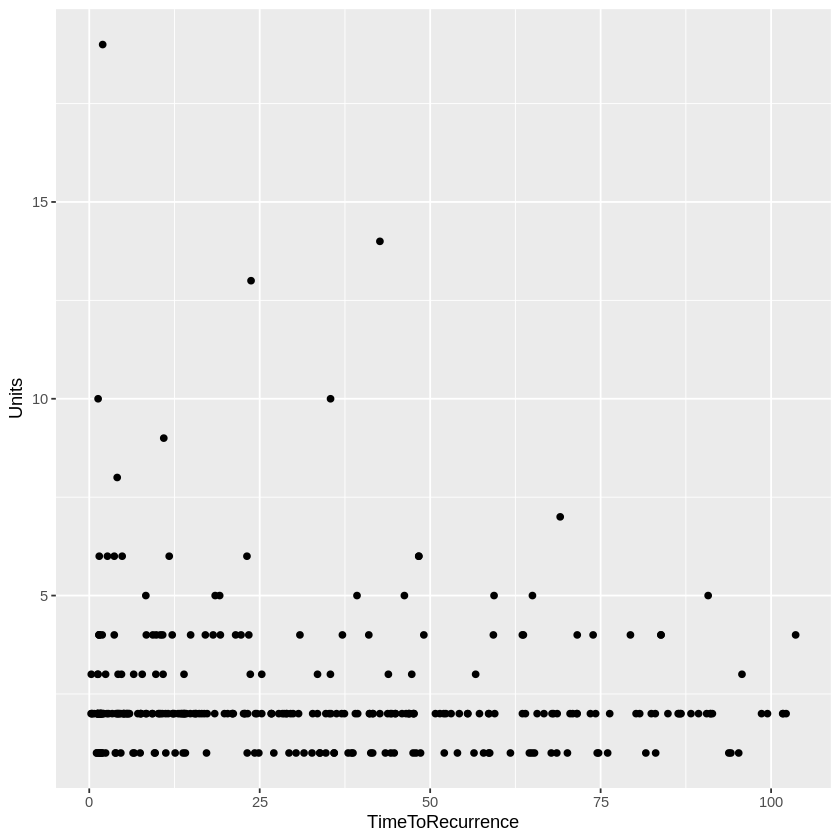

In [43]:
ggplot(data = dat) +
  geom_point(mapping = aes(x = TimeToRecurrence, y = Units))

integer(0)

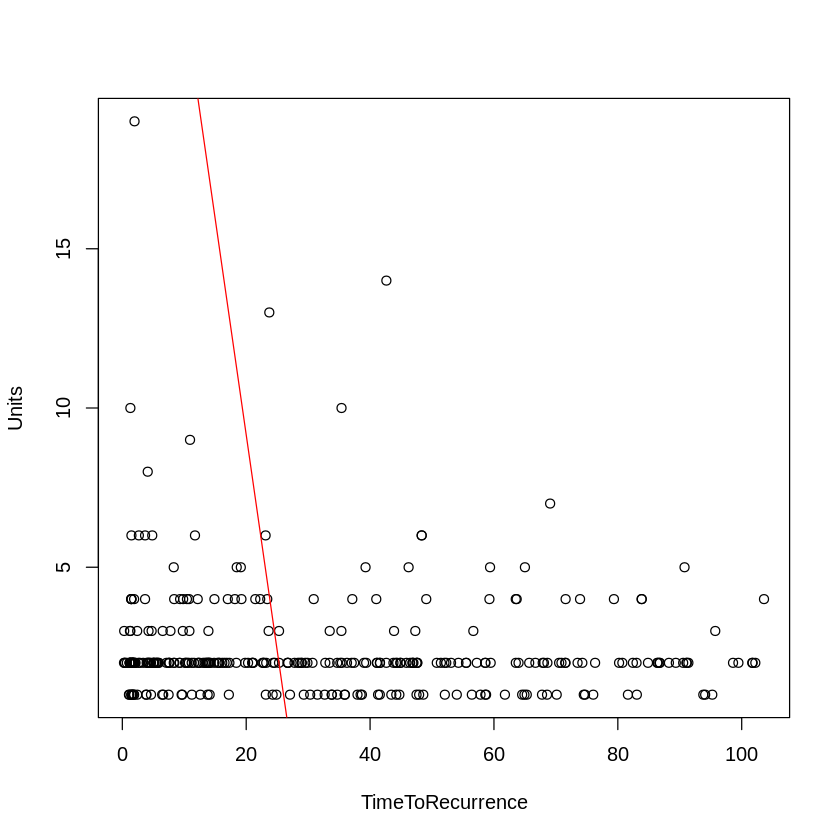

In [44]:
# We can look at any of these pairs in more detail by running them separately:
attach(dat)
p<- plot(TimeToRecurrence, Units)+
  abline(lm(TimeToRecurrence~Units), col='red')  #this adds a regression line
p

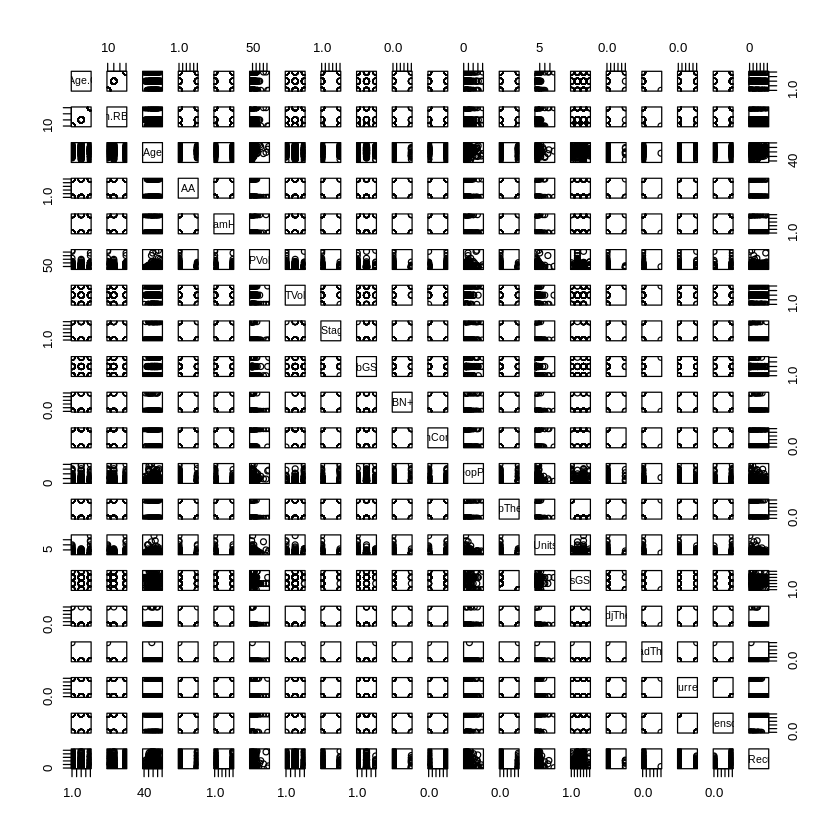

In [45]:
# The pairs function in base R will produce a matrix of scatterplots for each combination of variables
# - let's focus on the continuous variables first
pairs(dat)

The following objects are masked from dat (pos = 3):

    AA, AdjRadTherapy, Age, AnyAdjTherapy, bGS, BN+, Censor, FamHx,
    Median.RBC.Age, OrganConfined, PreopPSA, PreopTherapy, PVol,
    RBC.Age.Group, Recurrence, sGS, T.Stage, TimeToRecurrence, TVol,
    Units




integer(0)

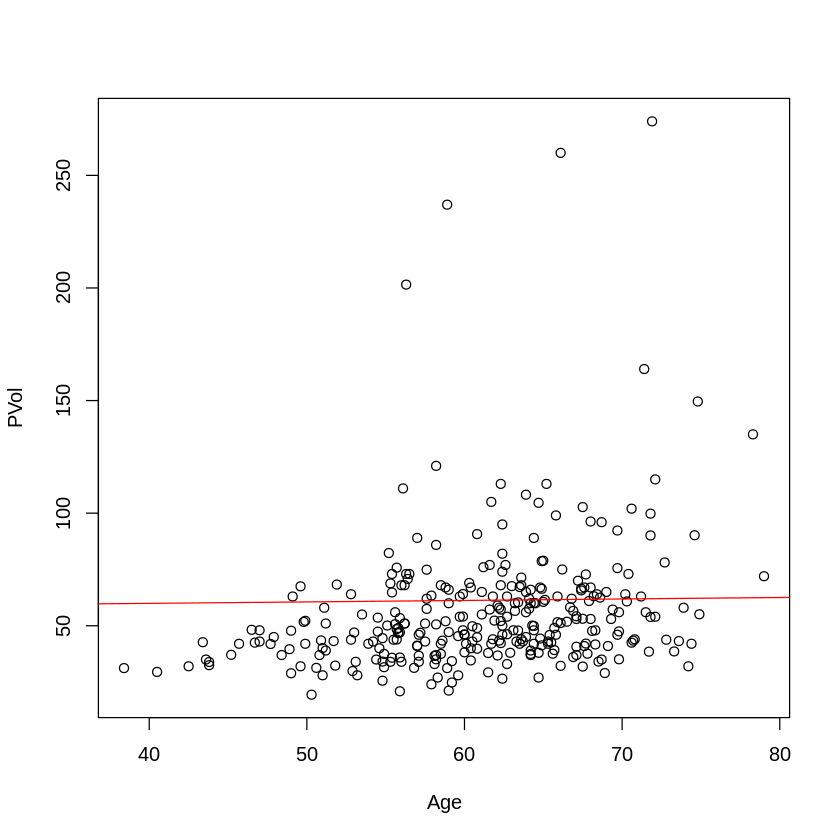

In [46]:
# We can look at any of these pairs in more detail by running them separately:
attach(dat)
p<- plot(Age,PVol)+
  abline(lm(Age~PVol), col='red')  #this adds a regression line
p

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“The following aesthetics were dropped during statistical transformation:
colour.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


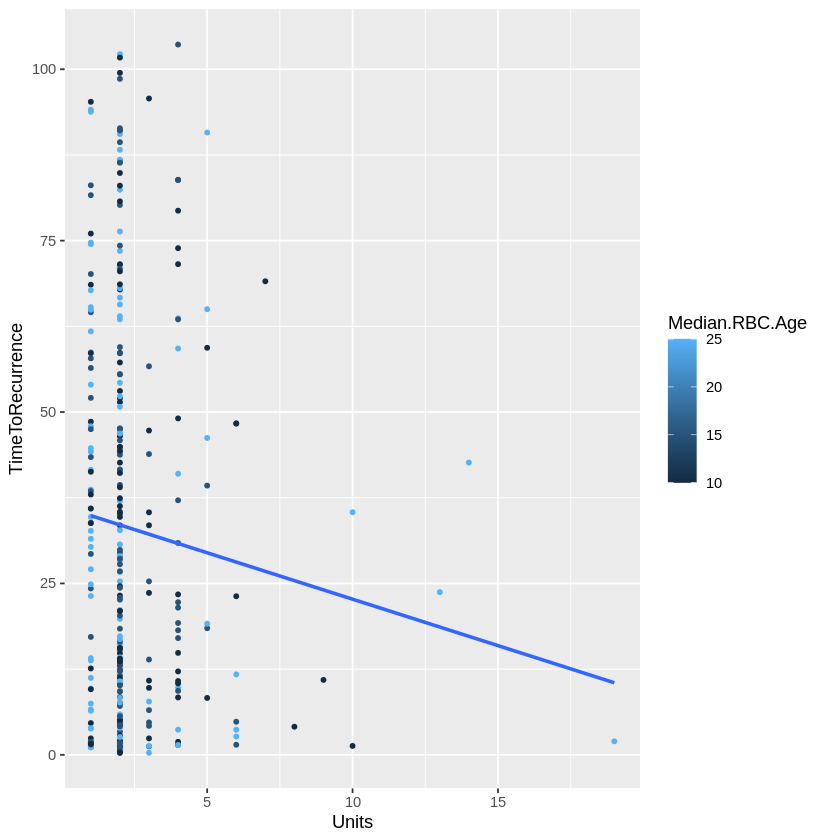

In [47]:
# Using ggplot we can also add in color depending on another variable - eg.Sex
ggplot(dat, aes(x=Units, y=TimeToRecurrence, color=Median.RBC.Age)) +
    geom_point(size=1)+
    geom_smooth(method = "lm", se = FALSE)  #this adds two regression lines

### Correlation Matrix

In [50]:
# Filter for numeric columns only to avoid the 'x must be numeric' error
numeric_dat <- dat %>% select(where(is.numeric))

# The cor() function produces a basic correlation matrix.
cormat <- round(cor(numeric_dat, method = "pearson", use = "complete.obs"), digits=2)
cormat

,Median.RBC.Age,Age,PVol,TVol,T.Stage,bGS,BN+,OrganConfined,PreopPSA,PreopTherapy,Units,sGS,AnyAdjTherapy,AdjRadTherapy,Recurrence,Censor,TimeToRecurrence
Median.RBC.Age,1.00,-0.06,-0.07,-0.06,-0.04,-0.02,-0.02,0.10,0.04,0.00,-0.02,-0.01,0.06,-0.06,0.01,-0.01,0.01
Age,-0.06,1.00,0.30,-0.07,-0.01,0.06,-0.15,-0.08,-0.03,-0.06,0.00,0.09,-0.05,-0.03,0.02,-0.02,0.07
PVol,-0.07,0.30,1.00,-0.19,-0.09,0.01,-0.07,0.06,0.24,-0.14,0.07,-0.01,-0.07,-0.02,0.00,0.00,0.08
TVol,-0.06,-0.07,-0.19,1.00,0.32,0.29,0.23,-0.48,0.29,0.12,-0.12,0.21,0.20,0.07,0.31,-0.31,-0.11
T.Stage,-0.04,-0.01,-0.09,0.32,1.00,0.45,0.33,-0.38,0.28,0.29,-0.10,-0.05,0.23,-0.02,0.25,-0.25,-0.15
bGS,-0.02,0.06,0.01,0.29,0.45,1.00,0.17,-0.37,0.28,0.34,-0.02,0.03,0.24,0.13,0.35,-0.35,-0.26
BN+,-0.02,-0.15,-0.07,0.23,0.33,0.17,1.00,-0.15,0.26,0.30,-0.07,-0.18,0.34,-0.01,0.13,-0.13,-0.07
OrganConfined,0.10,-0.08,0.06,-0.48,-0.38,-0.37,-0.15,1.00,-0.20,-0.16,0.03,-0.12,-0.21,-0.08,-0.25,0.25,0.11
PreopPSA,0.04,-0.03,0.24,0.29,0.28,0.28,0.26,-0.20,1.00,0.22,0.02,-0.09,0.15,0.03,0.25,-0.25,-0.10
PreopTherapy,0.00,-0.06,-0.14,0.12,0.29,0.34,0.30,-0.16,0.22,1.00,0.00,-0.75,0.21,0.15,0.25,-0.25,-0.10


In [51]:
if(!"corrplot" %in% installed.packages()) install.packages("corrplot", repos = "https://cran.ms.unimelb.edu.au")
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



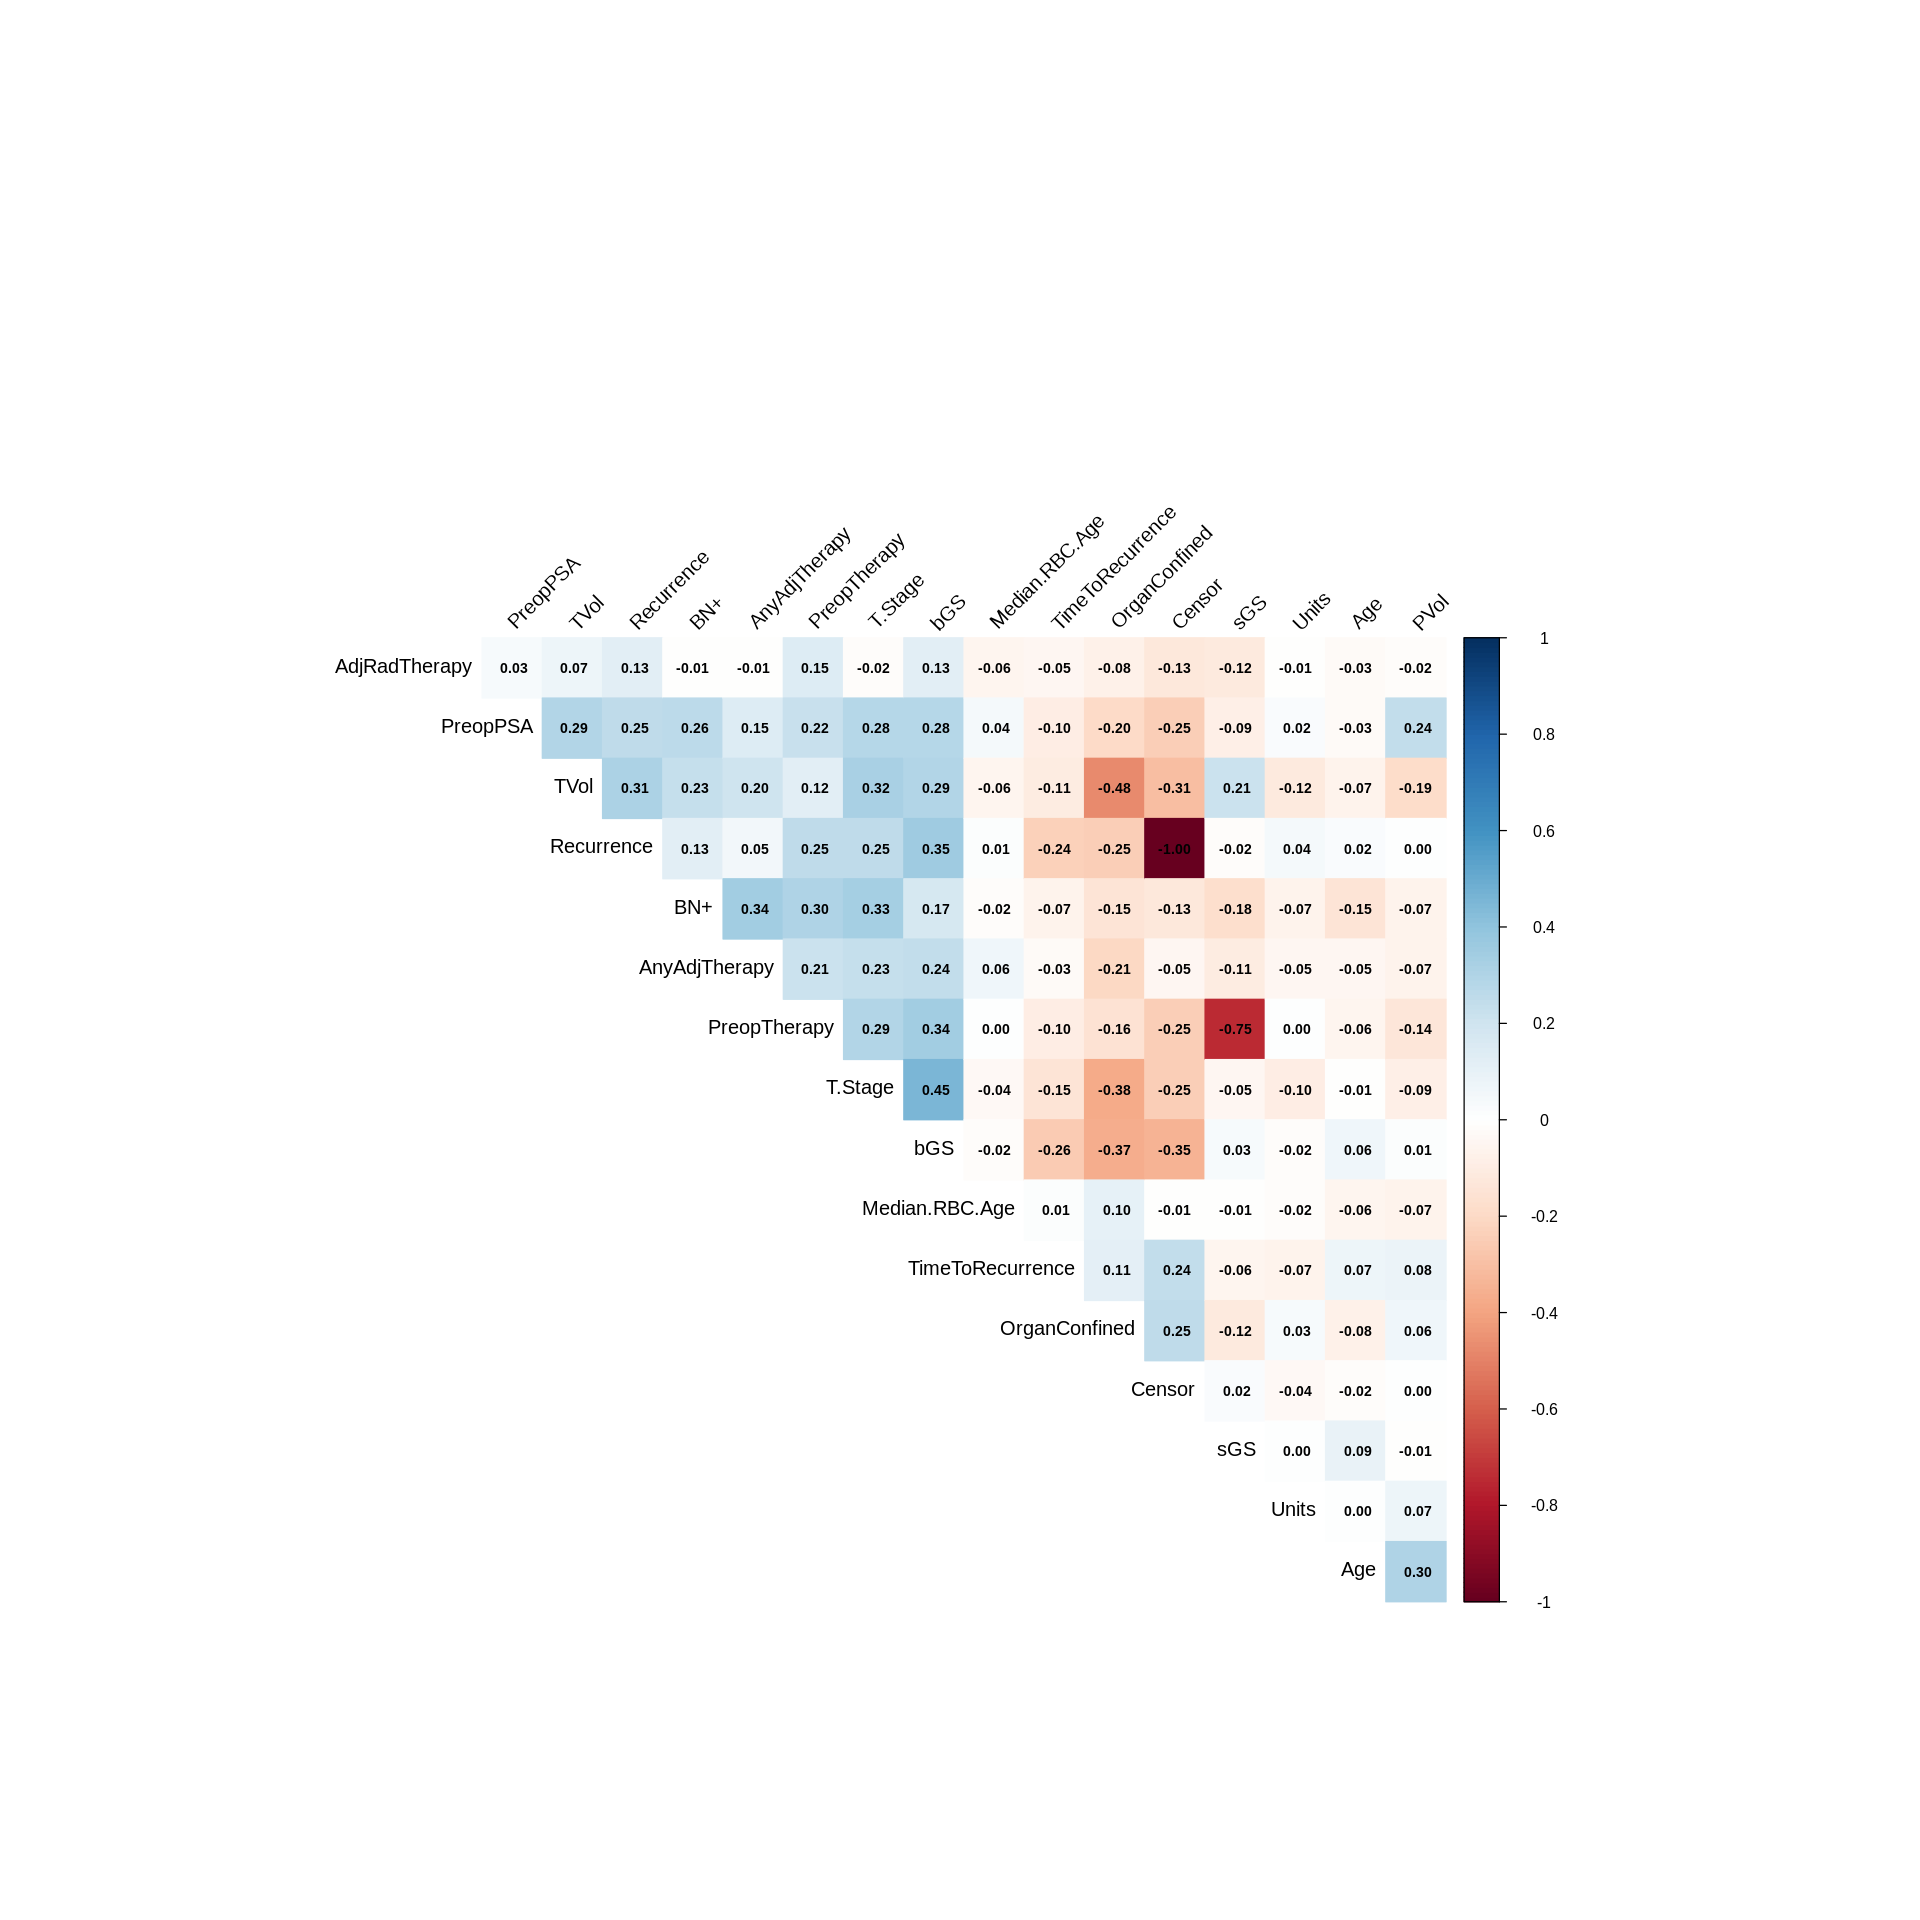

In [54]:
# Increase plot size for better visibility
options(repr.plot.width = 16, repr.plot.height = 16)

# Generate the heatmap
corrplot(cormat, method = "color",
         type = "upper",
         order = "hclust",
         tl.col = "black",
         tl.srt = 45,
         addCoef.col = "black",
         number.cex = 0.7,
         diag = FALSE)

### Summary of Correlation Analysis

Based on the Pearson correlation matrix and heatmap, we can draw the following conclusions regarding the clinical variables in the `blood_storage` dataset:

*   **Perfect Multicollinearity:** `RBC.Age.Group` and `Median.RBC.Age` (0.98 correlation) are nearly identical. In statistical modelling, only one of these should be included to avoid redundancy.
*   **Disease Progression Indicators:** There are moderate to strong positive correlations between **Tumor Volume (TVol)**, **Clinical Stage (T.Stage)**, and **Biopsy Gleason Score (bGS)**. These features likely provide complementary information about cancer severity.
*   **Organ Confinement:** `OrganConfined` shows a strong inverse relationship with `TVol` (-0.48), confirming that larger tumor volumes are less likely to be localized.
*   **Recurrence Markers:** `Recurrence` and `Censor` are perfectly inversely correlated (-1.00), representing the same clinical outcome from different directions.

Analytical notes:
Strongest correlations: RBC.Age.Group and Median.RBC.Age(0.98) --> multicolineraity?

Moderate correlations: PVol and Age (0.30), TVol and T.Stage (0.32), TVol and bGS(0.29), TVol and BN+(0.23), TVol and PreopPSA(0.29). T.Stage and PreopPSA(0.28), bGS and T.Stage(0.45), bGS and PreopTherapy(0.34). BN+ and AnyAdjTherapy(0.34)

Negative: TVol and OrganConfined(-0.48)